# All Shape Types Explorer

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Grid Setup

In [2]:
grid_size = 100
x = np.linspace(-1, 1, grid_size)
X, Y = np.meshgrid(x, x)

### Defining Shapes

In [3]:
# Define Shapes
shape_names = ["Ellipse", "Rectangle", "Annulus (Ring)", "Two Circles"]

shapes = [
    {
        "type": "ellipse",
        "a": 0.6, "b": 0.3,
        "theta": np.pi/4,
        "center": (0.0, 0.0),
    },
    {
        "type": "rectangle",
        "width": 0.8, "height": 0.4,
        "theta": np.pi/6,
        "center": (0.0, 0.0),
    },
    {
        "type": "annulus",
        "outer_radius": 0.7,
        "inner_radius": 0.3,
        "center": (0.0, 0.0),
    },
    {
        "type": "two_circles",
        "radius1": 0.3, "center1": (-0.4, 0.3),
        "radius2": 0.25, "center2": (0.4, -0.2),
    },
]

### Function to compute mask

In [4]:
def compute_mask(shape, X, Y):
    t = shape["type"]
    match t:
        case "ellipse":
            a = shape["a"]
            b = shape["b"]
            theta = shape["theta"]
            cx, cy = shape["center"]
            x_shift = X - cx
            y_shift = Y - cy
            x_rot = x_shift * np.cos(theta) + y_shift * np.sin(theta)
            y_rot = -x_shift * np.sin(theta) + y_shift * np.cos(theta)
            mask = (x_rot / a) ** 2 + (y_rot / b) ** 2 <= 1.0
            return mask
        case "rectangle":
            width = shape["width"]
            height = shape["height"]
            theta = shape["theta"]
            cx, cy = shape["center"]
            x_shift = X - cx
            y_shift = Y - cy
            x_rot = x_shift * np.cos(theta) + y_shift * np.sin(theta)
            y_rot = -x_shift * np.sin(theta) + y_shift * np.cos(theta)
            mask = (np.abs(x_rot) <= width / 2) & (np.abs(y_rot) <= height / 2)
            return mask
        case "annulus":
            outer_radius = shape["outer_radius"]
            inner_radius = shape["inner_radius"]
            cx, cy = shape["center"]
            dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
            mask = (dist <= outer_radius) & (dist >= inner_radius)
            return mask
        case "two_circles":
            radius1 = shape["radius1"]
            cx1, cy1 = shape["center1"]
            radius2 = shape["radius2"]
            cx2, cy2 = shape["center2"]
            dist1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
            dist2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
            mask = (dist1 <= radius1) | (dist2 <= radius2)
            return mask
        case _:
            raise ValueError(f"Unsupported shape type: {t}")

### Plotting all the shapes

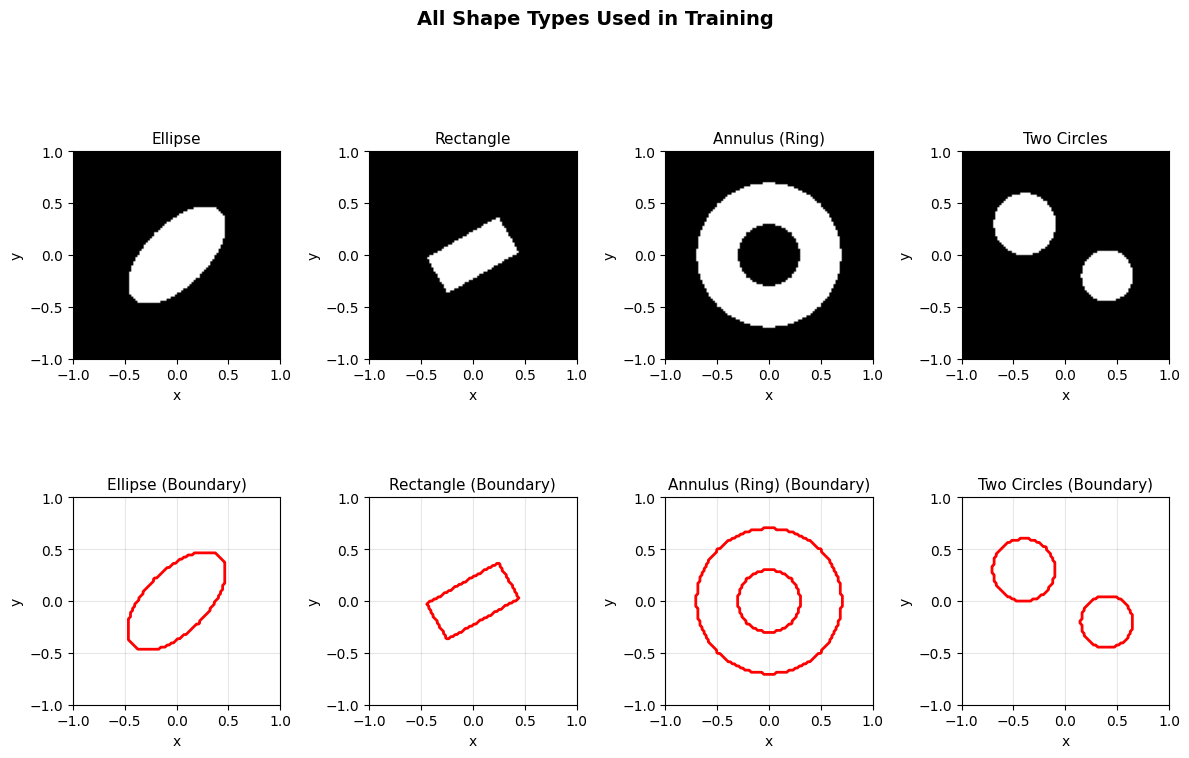

In [5]:
fig = plt.figure(figsize=(12, 8))

for i, shape in enumerate(shapes, start=1):
    mask = compute_mask(shape, X, Y)
    # Top row: mask image
    ax1 = fig.add_subplot(2, 4, i)
    ax1.imshow(
        mask.astype(float),
        extent=[x.min(), x.max(), x.min(), x.max()],
        origin="lower",
        cmap="gray"
    )
    ax1.set_title(shape_names[i-1], fontsize=11)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_aspect("equal")
    # Bottom row: boundary only
    ax2 = fig.add_subplot(2, 4, i + 4)
    ax2.contour(X, Y, mask.astype(float), levels=[0.5], colors="r", linewidths=2)
    ax2.set_title(f"{shape_names[i-1]} (Boundary)", fontsize=11)
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_aspect("equal")
    ax2.grid(True, alpha=0.3)
    
fig.suptitle("All Shape Types Used in Training", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()